In [2]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram

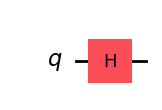

In [3]:

# Create a circuit with one qubit
circuit = QuantumCircuit(1)

# Add a Hadamard (H) gate on qubit 0, to create a superposition
circuit.h(0)

# Draw the circuit diagram. Delete "mpl" to get a text diagram.
circuit.draw("mpl")

In [4]:
# Now simulate the circuit by calculating the effect on state vectors.
# Set the initial state of the simulator to |0>
# The state vector has two coefficients, both 0
state = Statevector.from_int(0, 2)

# Apply the circuit to the state
state = state.evolve(circuit)

# Display using latex. This requires the pylatexenc module.
# Omit "latex" to get a numerical (not algebraic) view of the state vector.
state.draw("latex")
# state.draw()

<IPython.core.display.Latex object>

In [5]:
# A different way of dislaying the state, again using latex
from qiskit.visualization import array_to_latex

array_to_latex(state)

<IPython.core.display.Latex object>

In [6]:
# The whole circuit is a unitary operator, which we can display.

U = Operator(circuit)
array_to_latex(U)

<IPython.core.display.Latex object>

In [7]:
# Or less beautifully:
U.data
# The format is a little bit odd. 0.j means the imaginary part is 0
# 0 is being displayed with a decimal point but no trailing 0
# j is used for the square root of -1, instead of i

array([[ 0.70710678+0.j,  0.70710678+0.j],
       [ 0.70710678+0.j, -0.70710678+0.j]])

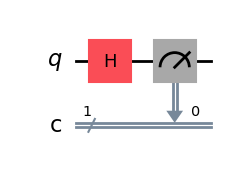

In [8]:
# Now reconstruct the circuit and add a measurement
# The second parameter of QuantumCircuit is the number of classical bits
circuit = QuantumCircuit(1,1)
circuit.h(0)

# The first list is the qubits to measure,
# the second list is the classical bits where the results go
circuit.measure([0],[0])
circuit.draw("mpl")

In [9]:
# We will need to transpile the circuit into QASM instructions for the back end

# Use BasicSimulator
backend = BasicSimulator()

# Compile / transpile
qc_compiled = transpile(circuit, backend)

# Run the circuit on the simulator.
# We've set the number of repeats of the circuit
# to be 1024, which is the default.
# The qubits start in state |0>
job_sim = backend.run(qc_compiled, shots=1024)

# Grab the results from the job (this doesn't produce any output).
result_sim = job_sim.result()

In [10]:
# The simplest way to see the results of the simulation
counts = result_sim.get_counts(qc_compiled)
print(counts)

# The results are not exactly half 0 and half 1, but should be close.
# There will be different results each time the previous cell is run.

{'0': 524, '1': 500}


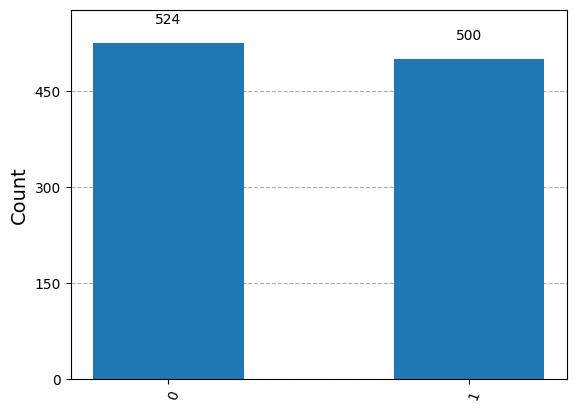

In [11]:
# We can also produce a graph

plot_histogram(counts)

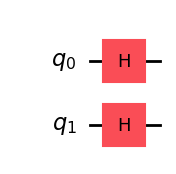

In [12]:
# Now let's move on to two qubits.
# Apply H to both qubits and see what we get.

circuit = QuantumCircuit(2)
circuit.h(0)
circuit.h(1)

circuit.draw("mpl")

In [13]:
state = Statevector.from_int(0, 4) # 4 is the number of basis states on 2 qubits
state = state.evolve(circuit)
state.draw("latex")

<IPython.core.display.Latex object>

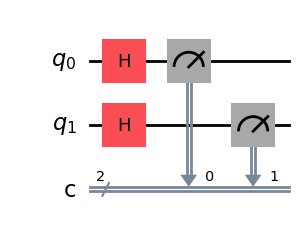

In [14]:
# Now measurement. This time we construct the measurement part
# of the circuit separately and then combine it with the first circuit.

# A new circuit with 2 qubits and 2 classical bits
meas = QuantumCircuit(2, 2)

# Map the quantum measurement to the classical bits
meas.measure(range(2), range(2))

# The Qiskit circuit object supports composition.
# Here the meas has to be first and front=True (putting it before)
# as compose must put a smaller circuit into a larger one.
qc = meas.compose(circuit, range(2), front=True)

qc.draw("mpl")

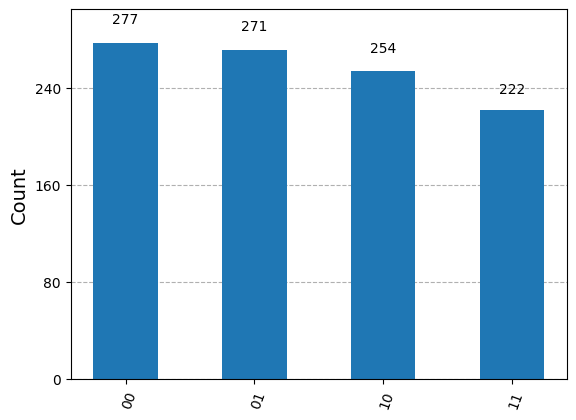

In [15]:
# Simulate again, using the same back end
qc_compiled = transpile(qc, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

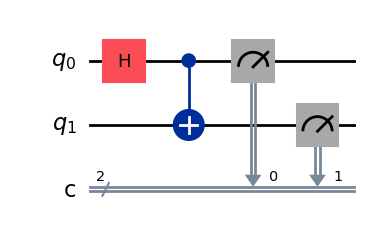

In [16]:
# Now for some entanglement.
# Construct a Bell state and measure both qubits to see that
# both measurements give the same result.

circuit = QuantumCircuit(2,2)
circuit.h(0)
circuit.cx(0,1) # cx means CNOT because it's a controlled version of x (negation)
circuit.measure(range(2),range(2))
circuit.draw("mpl")

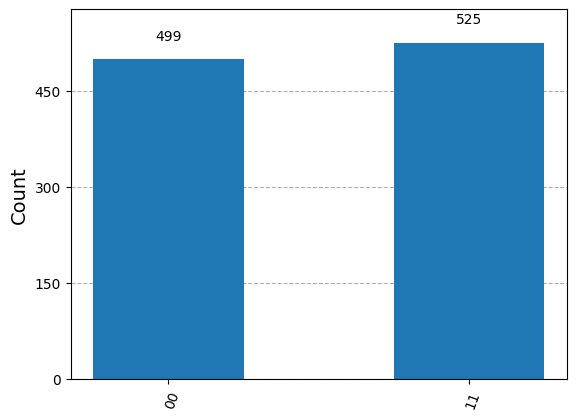

In [17]:
qc_compiled = transpile(circuit, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

Circuit for [Φ+] |00> + |11>:


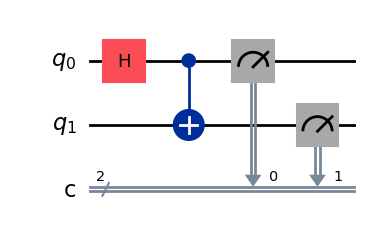

<IPython.core.display.Latex object>


Circuit for Φ- (|00> - |11>):


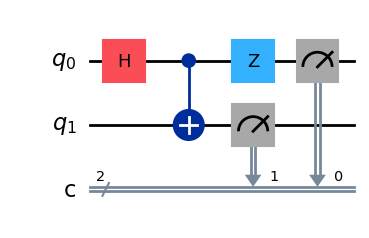

<IPython.core.display.Latex object>


Circuit for Ψ+ (|01> + |10>):


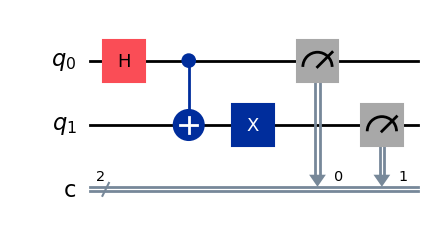

<IPython.core.display.Latex object>


Circuit for Ψ- (|01> - |10>):


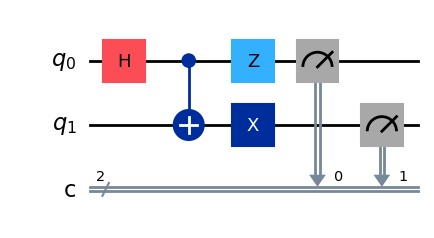

<IPython.core.display.Latex object>

Histograms:


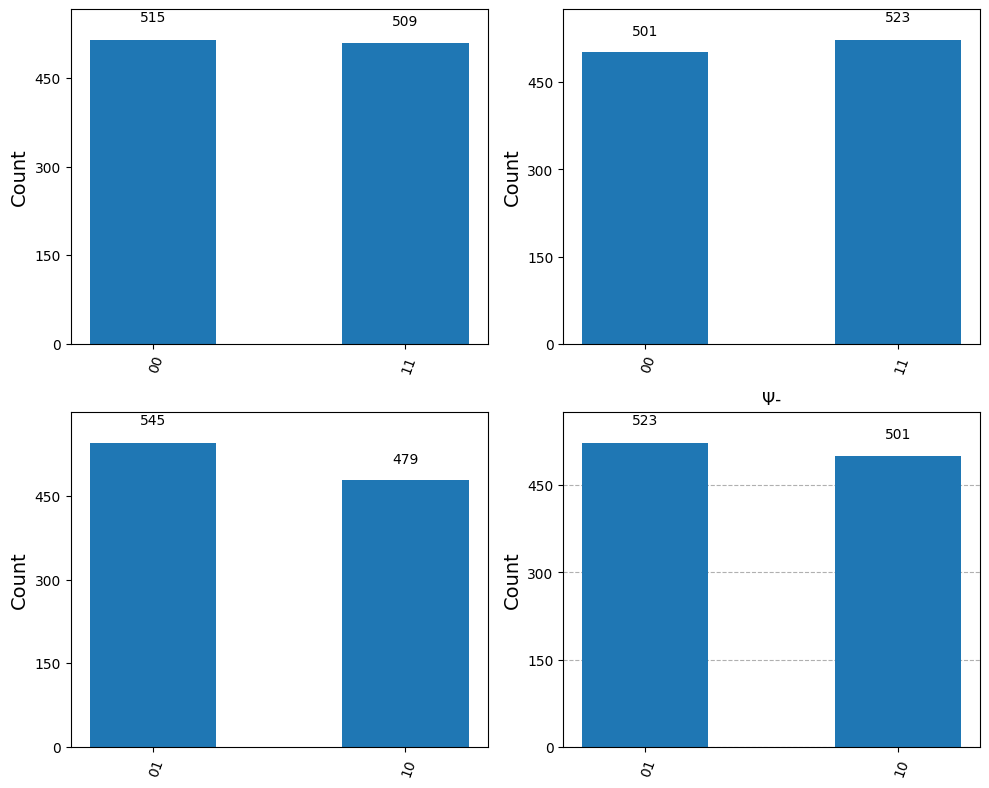

In [18]:
# EXERCISE
import matplotlib.pyplot as plt

# Make a copy here of the circuit that creates the Bell state 1/sqrt(2) ( |00> + |11> ).
# Φ+ (Phi Plus)
# Meaning: both qubits are the SAME, positive phase
circuit_bell = QuantumCircuit(2,2)
circuit_bell.h(0)
circuit_bell.cx(0,1)
circuit_bell.measure(range(2),range(2))
print("Circuit for [Φ+] |00> + |11>:")
display(circuit_bell.draw("mpl"))

# Check statevector (before measurement)
sv1 = Statevector.from_instruction(circuit_bell.remove_final_measurements(inplace=False))
display(array_to_latex(sv1.data, prefix="Φ+ = "))

qc_compiled = transpile(circuit_bell, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts1 = result_sim.get_counts(qc_compiled)

# Modify it to create the other Bell states:
#  a) 1/sqrt(2) ( |00> - |11> ),
#  b) 1/sqrt(2) ( |01> + |10> ),
#  c) 1/sqrt(2) ( |01> - |10> ).
# You will need to use X and Z gates. Check that your circuit is correct by displaying the state vector in each case.
# For each of the Bell states, repeat the simulation with measurements and check that the results are as expected.

# a) 1/sqrt(2) ( |00> - |11> )
# Φ- (Phi Minus)
# Meaning: same qubits, but NEGATIVE phase (Z gate adds minus sign)
circuit_bell_v2 = QuantumCircuit(2,2)
circuit_bell_v2.h(0)
circuit_bell_v2.cx(0,1)
circuit_bell_v2.z(0) # apply Z gate to qubit 0
circuit_bell_v2.measure(range(2),range(2))
print("\nCircuit for Φ- (|00> - |11>):")
display(circuit_bell_v2.draw("mpl"))

sv2 = Statevector.from_instruction(circuit_bell_v2.remove_final_measurements(inplace=False))
display(array_to_latex(sv2.data, prefix="Φ- = "))

qc_compiled = transpile(circuit_bell_v2, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts2 = result_sim.get_counts(qc_compiled)

# b) 1/sqrt(2) ( |01> + |10> )
# Ψ+ (Psi Plus)
# Meaning: qubits are DIFFERENT, positive phase
circuit_bell_v3 = QuantumCircuit(2,2)
circuit_bell_v3.h(0)
circuit_bell_v3.cx(0,1)
circuit_bell_v3.x(1)   # X flips qubit 1 → gives |01> and |10>
circuit_bell_v3.measure(range(2),range(2))

print("\nCircuit for Ψ+ (|01> + |10>):")
display(circuit_bell_v3.draw("mpl"))

sv3 = Statevector.from_instruction(circuit_bell_v3.remove_final_measurements(inplace=False))
display(array_to_latex(sv3.data, prefix="Ψ+ = "))

qc_compiled = transpile(circuit_bell_v3, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts3 = result_sim.get_counts(qc_compiled)


# c) 1/sqrt(2) ( |01> - |10> )
# Ψ- (Psi Minus)
# Meaning: qubits are DIFFERENT, negative phase
circuit_bell_v4 = QuantumCircuit(2,2)
circuit_bell_v4.h(0)
circuit_bell_v4.cx(0,1)
circuit_bell_v4.x(1)
circuit_bell_v4.z(0)   # adds negative phase
circuit_bell_v4.measure(range(2),range(2))

print("\nCircuit for Ψ- (|01> - |10>):")
display(circuit_bell_v4.draw("mpl"))

sv4 = Statevector.from_instruction(circuit_bell_v4.remove_final_measurements(inplace=False))
display(array_to_latex(sv3.data, prefix="Ψ+ = "))

qc_compiled = transpile(circuit_bell_v4, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts4 = result_sim.get_counts(qc_compiled)


# groups all 4 results side-by-side
fig, axes = plt.subplots(2, 2, figsize=(10,8))
print("Histograms:")
plot_histogram(counts1, ax=axes[0][0], title="Φ+")
plot_histogram(counts2, ax=axes[0][1], title="Φ-")
plot_histogram(counts3, ax=axes[1][0], title="Ψ+")
plot_histogram(counts4, ax=axes[1][1], title="Ψ-")

plt.tight_layout()
plt.show()



Circuit for 5-qubit GHZ state:


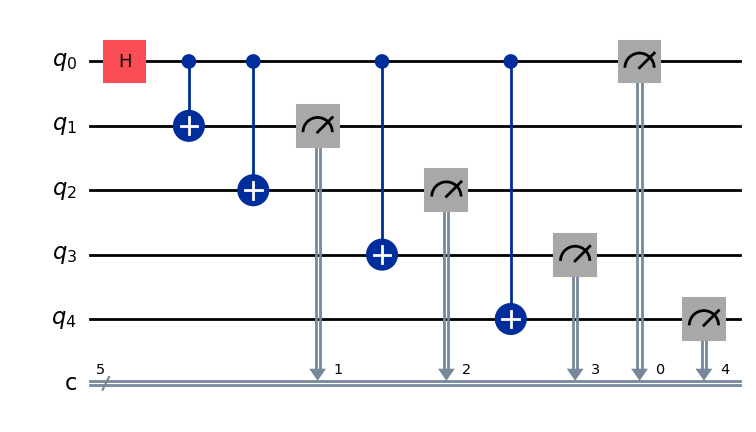

<IPython.core.display.Latex object>


Measurement counts: {'11111': 499, '00000': 525}


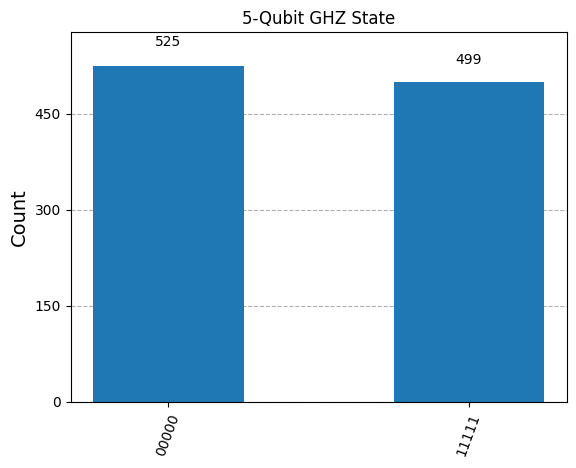

In [20]:
# EXERCISE

# The GHZ state on any number of qubits has the form  1/sqrt(2) ( |00...0> + |11...1> )
  # H(0) → CX(0,1) → CX(0,2) → CX(0,3) → ...

# The Bell state 1/sqrt(2) ( |00> + |11> ) is the case for two qubits.
  # H(0) → CX(0,1)

# Write code to construct a circuit that produces a GHZ state for any given number of qubits.
# Try simulating the circuit, with measurements. How many qubits can the simulator handle in a reasonable time?

n = 5   # number of qubits

ghz_circuit = QuantumCircuit(n,n)
ghz_circuit.h(0)  # 1st qubits into superposition
for i in range(1, n):  # entangle all other qubits with qubit 0
    ghz_circuit.cx(0, i)

ghz_circuit.measure(range(n),range(n)) # measure all qubits
print(f"\nCircuit for {n}-qubit GHZ state:")
display(ghz_circuit.draw("mpl"))

# STATEVECTOR (before measurement)
sv = Statevector.from_instruction(ghz_circuit.remove_final_measurements(inplace=False))
display(array_to_latex(sv.data, prefix="Statevector (raw)"))


# SIMULATION
qc_compiled = transpile(ghz_circuit, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)

print("\nMeasurement counts:", counts)

display(plot_histogram(counts, title=f"{n}-Qubit GHZ State"))
